# Phân đoạn tiền cảnh thời gian thực và làm mờ có chọn lọc trên GPU

**CSC14116 — Applied Parallel Programming** <br>
Huỳnh Lê Hải Dương (22127081) <br>
Nguyễn Đức Tín (22127415) <br>
Repo: `github.com/Sn-cpp/Adaptive-Gaussian-Mixture-Model` · **Số liệu hiệu năng ghi trên Tesla T4** · các cell chạy sống dùng máy hiện tại

**1** Giới thiệu <br>
**2** Phương pháp <br>
**3** Đánh giá <br>
**4** Thảo luận <br>
**5** Kết luận <br>

*Các biểu đồ dùng record đã commit (`RESULTS-T4.md`, `benchmarks/records/`) hoặc tính lại trực tiếp. Những cell có dấu ⏱ mất vài phút để chạy, nên kết quả được ghi nhận gần nhất được đặt bên cạnh.*

In [1]:
import matplotlib.pyplot as plt, numpy as np

# Palette validated for CVD safety (dataviz six-checks): identity is fixed —
# v0 blue, v1 amber, v2 red (red = the submitted version, everywhere).
C = {"v0": "#2a78d6", "v1": "#eda100", "v2": "#c0392b",
     "ink": "#1a1a19", "muted": "#8a8a85", "good": "#008300"}
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": .25,
    "grid.linestyle": "--", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"]})

def take(msg):
    """One bold takeaway line under a figure — the sentence to say out loud."""
    from IPython.display import display, Markdown
    display(Markdown(f"**▸ {msg}**"))

In [2]:
import os, subprocess, sys

def repo_root():
    for c in (os.getcwd(), "/content/project", os.path.join(os.getcwd(), "project")):
        if os.path.isdir(os.path.join(c, ".git")) and os.path.exists(os.path.join(c, "gmm_mask")):
            return c
    return None

root = repo_root()
if root is None:
    dest = "/content/project" if os.path.isdir("/content") else "project"
    subprocess.run(["git", "clone", "-q", "--depth", "1",
        "https://github.com/Sn-cpp/Adaptive-Gaussian-Mixture-Model.git", dest], check=True)
    root = dest
os.chdir(root); sys.path.insert(0, root)
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "numba<0.62"], capture_output=True)

import cv2, numba, platform
from numba import cuda
HAS_GPU = cuda.is_available()
base = subprocess.run(["git","rev-parse","--short","HEAD"], capture_output=True, text=True).stdout.strip()
impl_clean = subprocess.run(["git","diff","--quiet","HEAD","--",".",":(exclude)notebook.ipynb"]).returncode == 0
print(f"commit gốc {base} | các file hiện thực sạch: {impl_clean}")
print(f"python {platform.python_version()} | cv2 {cv2.__version__} | numba {numba.__version__} | GPU: {HAS_GPU}")

commit gốc 3f64491 | các file hiện thực sạch: True
python 3.12.13 | cv2 5.0.0 | numba 0.61.2 | GPU: False


In [3]:
import glob, socket, urllib.request, zipfile, hashlib
socket.setdefaulttimeout(30)
HIGHWAY = os.environ.get("HIGHWAY_DIR", "highway")

def usable(d):
    return os.path.isdir(os.path.join(d, "input")) and os.path.isdir(os.path.join(d, "groundtruth"))

if not usable(HIGHWAY):
    local = glob.glob("highway.zip") + glob.glob("/content/highway.zip")
    if not local:
        # original CDnet hosts are offline; this is the team's mirror (CDnet citation on the card)
        url = ("https://huggingface.co/datasets/haiduonghuynhle/"
               "changedetection-2012-highway/resolve/main/highway.zip")
        try:
            urllib.request.urlretrieve(url, "highway.zip"); local = ["highway.zip"]
        except Exception as e:
            print("tải xuống thất bại:", e)
    if local:
        with zipfile.ZipFile(local[0]) as z: z.extractall(".")

HAS_DATA = usable(HIGHWAY)
os.environ["HIGHWAY_DIR"] = HIGHWAY
print("đã có CDnet highway:", HAS_DATA)

import numpy as np
def load_sequence(n, size=(320, 240)):
    """Frames for the figures: CDnet if present, else labelled synthetic."""
    if HAS_DATA:
        out = [cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg") for i in range(1, n + 1)]
        out = [f for f in out if f is not None]
        if out: return out, "CDnet highway"
    import bench_post
    return bench_post.make_frames(n, size), "tổng hợp (chỉ để minh họa)"

đã có CDnet highway: True


## 1 · Giới thiệu

**Đầu vào:** video giao thông từ camera cố định — một luồng frame BGR (CDnet 320×240 đến cảnh quay thực 1920×1080).
**Đầu ra, với mỗi frame:** (a) mask tiền cảnh nhị phân — 255 tại xe đang chuyển động, 0 ở nơi khác; (b) frame tổng hợp — xe giữ nét, mọi vùng còn lại được Gaussian blur.
**Mục tiêu:** tạo cả hai theo thời gian thực (≥30 FPS tại 1080p), đồng thời chấm chất lượng mask theo ground truth gán nhãn thủ công: **CDnet `baseline/highway`**, frame 470–1700, loại các pixel don't-care.

*Phạm vi dữ liệu: các host CDnet đang offline, nên nhóm dùng mirror trên HuggingFace; sha256 của dữ liệu được ghi trong `benchmarks/records/eval_highway_full.txt`. Không có bộ dữ liệu 1080p đã gán nhãn, vì vậy 1080p chỉ được dùng để đo throughput.*

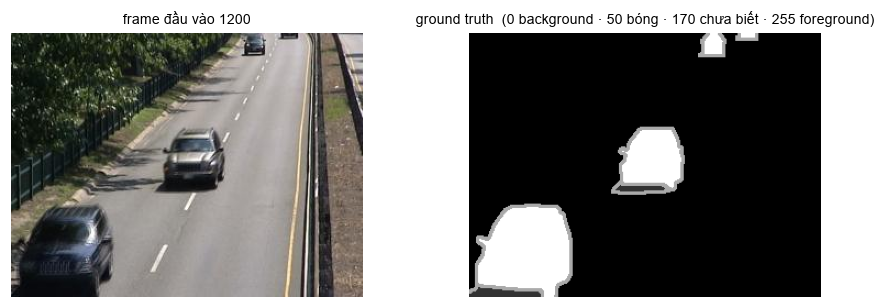

**▸ Mọi số liệu chất lượng trong notebook đều được chấm theo các nhãn thủ công này.**

In [4]:
if HAS_DATA:
    i = 1200
    frame = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
    gt    = cv2.imread(f"{HIGHWAY}/groundtruth/gt{i:06d}.png", 0)
    fig, ax = plt.subplots(1, 2, figsize=(8.5, 2.9))
    ax[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); ax[0].set_title(f"frame đầu vào {i}", fontsize=9)
    ax[1].imshow(gt, cmap="gray"); ax[1].set_title("ground truth  (0 background · 50 bóng · 170 chưa biết · 255 foreground)", fontsize=9)
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()
    take("Mọi số liệu chất lượng trong notebook đều được chấm theo các nhãn thủ công này.")

### 1.1 · Vì sao dùng GPU

| | |
|---:|---|
| **2 073 600** | pixel trong mỗi frame 1080p |
| **25 giá trị/px → 207 MB** | trạng thái mô hình được giữ trên GPU và đọc ở mỗi frame (5 Gaussian × 5 số, mỗi số 4 byte) |
| **3 035 ms/frame** | Python tuần tự tại 480p (`benchmarks/records/`) |
| **30 FPS** | mục tiêu thời gian thực |

Mỗi pixel được cập nhật độc lập, nên một frame ánh xạ thành 2 triệu thread (đơn vị công việc song song nhỏ). Chỉ có một giai đoạn không phù hợp với cách này; §2.5 giải thích nguyên nhân.

## 2 · Phương pháp

Một thuật toán — MOG2 (Zivkovic 2004), tức mixture of Gaussians theo từng pixel — và năm hiện thực: Sequential Python, Numba CPU, cùng CUDA v0, v1, v2. Hai bản CPU lần lượt là đặc tả dễ đọc và baseline biên dịch công bằng; ba bản CUDA tạo thành thang tối ưu bên dưới. CUDA là nền tảng chạy song song nhiều công việc nhỏ trên GPU.

### Thuật toán trong 14 dòng — `mog2_step`, chạy một lần cho mỗi pixel ở mỗi frame

```text
với mỗi pixel (y, x), dùng một thread:
    bg_weight = 0;  matched = False
    với mỗi Gaussian mode k = 0..K-1, luôn sắp giảm dần theo weight:
        dist² = ‖pixel − mean_k‖²                      # YCrCb, float32
        nếu dist² < Tb·var_k:                          # khớp lỏng → bằng chứng thuộc background
            bg_weight += w_k                           # ← nhánh tạo nên câu chuyện 2 pixel (§3.1)
            nếu tổng weight đã đếm < TB: pixel thuộc background
        nếu chưa matched và dist² < Tg·var_k:          # khớp chặt → cập nhật mode này
            matched = True
            w_k += α;  mean_k, var_k tiến về pixel (tốc độ α/w_k);  đưa k lên đúng thứ tự
        w_k = (1−α)·w_k − α·CT                         # suy giảm; bỏ mode nếu thấp hơn ngưỡng sàn
    chuẩn hóa các weight;  bg_prob[y,x] = bg_weight
    nếu chưa matched: thay mode yếu nhất bằng (pixel, var_init, weight α)
```

| Tham số | Giá trị (`settings.py`, = mặc định của OpenCV) | Ý nghĩa |
|---|---|---|
| K | 5 | số Gaussian mode cho mỗi pixel |
| α | 1/250 sau warm-up (`history` 250) | learning rate — background thích nghi nhanh đến mức nào |
| **Tb** | 16 | mức khớp lỏng, tính theo đơn vị variance: “đủ gần để được tính là background” |
| **Tg** | 9 | mức khớp chặt: “đủ gần để *cập nhật* mode này” (Tb > Tg) |
| **TB** | 0.9 | tổng weight tích lũy để tạo thành mô hình background |
| CT | 0.05 | prune rate — mode xuất hiện quá ít sẽ bị xóa |
| var_init / clamp | 15, [4, 75] | variance của mode mới và các cận của nó |

Mask phát hành sau cùng áp ngưỡng confidence: là foreground khi `bg_prob < 0.5` (§2.6).

### 2.2 · Thang tối ưu

| Phiên bản | Bậc thang | Thay đổi |
|---|---|---|
| **v0** | L1 port ngây thơ | model kernel (hàm GPU chạy song song), mỗi pixel một thread. Đúng — nhưng mọi giai đoạn còn lại vẫn chạy trên host. |
| **v1** | L2 memory | giảm upload frame từ 12 xuống 3 B/px; phép đổi YCrCb số nguyên, threshold, median, blur và composite đều chuyển lên device — mask không còn đi khứ hồi qua bus |
| **v2** | L2 + L3 | fuse threshold vào cuối model kernel (bớt một lần launch và một lượt quét toàn frame); dựng lại median và blur bằng shared-memory tile (khối dữ liệu on-chip truy cập nhanh) |

Trạng thái có dạng planar (`means[k][c][y][x]`) trong **mọi** phiên bản, nên ngay từ v0, các thread lân cận đọc các byte lân cận (coalesced). Lợi ích của v1 đến từ việc di chuyển ít dữ liệu hơn, không phải layout mới. Fusion dừng đúng nơi tính đúng đắn sẽ bị phá vỡ: median cần 25 pixel lân cận đã threshold, và nếu tính lại chúng bên trong model kernel thì state update sẽ bị áp dụng hai lần. v1 còn hiện thực adaptive alpha và neighbor propagation — mặc định tắt, không được chấm điểm và không nằm trong shipping path.

### Mỗi phiên bản mang lại gì — số đo ghi nhận theo từng frame

| Phiên bản | Mỗi frame (cảnh quay thực 1080p nếu không ghi khác) | FPS | Nguồn |
|---|---|---|---|
| Sequential Python | 3 034.62 ms tại 480p (L0 baseline) | 0.3 | `RESULTS-T4.md` §3 |
| Numba CPU | 145.79 ms | 7 | `benchmarks/records/t4_final_run.txt` |
| CUDA v0 | 53.64 ms | 19 | cùng record |
| CUDA v1 | 13.41 ms | 75 | cùng record |
| CUDA v2 | 11.07 ms | 90 | cùng record |

In [5]:
# Recorded on a Colab Tesla T4 (RESULTS-T4.md, benchmarks/records/). Quoted, because charts need a
# GPU-measured input and this notebook must render on a CPU-only machine too.
SIZES = ["480p", "720p", "1080p"]
T4 = {"v0": {"ms": [10.22, 20.82, 55.03], "fps": [97.9, 48.0, 18.2]},
      "v1": {"ms": [3.74, 6.98, 13.75],   "fps": [267.3, 143.3, 72.8]},
      "v2": {"ms": [3.26, 6.02, 11.26],   "fps": [307.1, 166.2, 88.8]}}
BUS = {"v0": [6.97, 15.67, 35.25], "gpu": [3.28, 7.37, 16.59]}
PERSTAGE = {  # ms/frame per stage, [480p, 720p, 1080p]
    "v0": {"mask production": [6.278, 12.302, 35.924], "host fill_holes": [0.965, 2.155, 4.622],
           "blur + composite": [3.385, 6.333, 14.383]},
    "v1": {"mask production": [1.175, 1.940, 3.651],   "host fill_holes": [0.877, 1.938, 4.441],
           "blur + composite": [1.616, 3.083, 6.057]},
    "v2": {"mask production": [1.149, 1.984, 3.510],   "host fill_holes": [0.882, 1.972, 4.719],
           "blur + composite": [1.108, 2.044, 3.665]}}
# Measured 2026-08-21 on a Colab T4 at commit 786b54b — one session for all five
# implementations, real 1080p traffic clip (Pexels 4791721), decode excluded.
# Record: benchmarks/records/t4_final_run2.txt. numba..v2: 152 timed frames;
# sequential: 8/6/4/3 frames (it is slow), same decode and same full pipeline.
REALFOOTAGE_T4 = {
    "tiers": ["240p", "480p", "720p", "1080p"],
    "seq":   {"ms": [893.9, 4327.1, 9708.6, 21725.2], "fps": [1.12, 0.23, 0.10, 0.05]},
    "numba": {"ms": [6.11, 35.08, 64.47, 133.03], "fps": [164, 29, 16, 8]},
    "v0":    {"ms": [4.42, 10.83, 22.23, 54.71],  "fps": [226, 92, 45, 18]},
    "v1":    {"ms": [1.42, 3.90, 6.66, 13.41],    "fps": [706, 256, 150, 75]},
    "v2":    {"ms": [1.30, 3.39, 5.57, 11.24],    "fps": [769, 295, 179, 89]},
}

### 2.3 · Memory: giảm một nửa lưu lượng qua bus

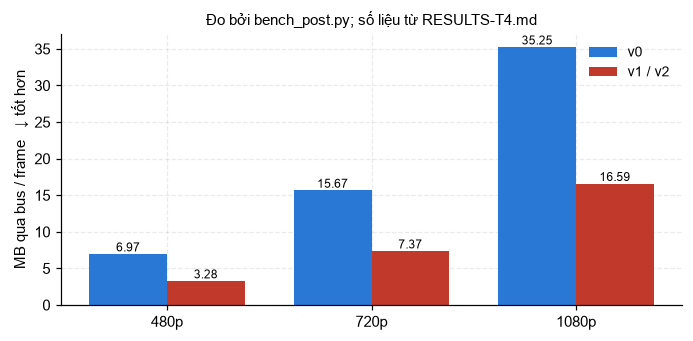

**▸ Tại 1080p: 35.25 → 16.59 MB mỗi frame. Frame được upload dưới dạng 3 byte mỗi pixel thay vì 12, và confidence map không còn phải tải ngược về.**

In [6]:
x = np.arange(3)
fig, ax = plt.subplots(figsize=(6.4, 3.2))
b1 = ax.bar(x - .19, BUS["v0"], .38, label="v0", color=C["v0"])
b2 = ax.bar(x + .19, BUS["gpu"], .38, label="v1 / v2", color=C["v2"])
ax.bar_label(b1, fmt="%.2f", fontsize=8); ax.bar_label(b2, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(SIZES); ax.set_ylabel("MB qua bus / frame   ↓ tốt hơn")
ax.legend(frameon=False, fontsize=9)
ax.set_title("Đo bởi bench_post.py; số liệu từ RESULTS-T4.md", fontsize=9.5)
plt.tight_layout(); plt.show()
take(f"Tại 1080p: {BUS['v0'][2]} → {BUS['gpu'][2]} MB mỗi frame. Frame được upload dưới dạng "
     f"3 byte mỗi pixel thay vì 12, và confidence map không còn phải tải ngược về.")

- **Cách đọc:** số byte đi qua PCIe bus (host ↔ GPU) ở mỗi frame; cột càng thấp thì chi phí truyền dữ liệu càng nhỏ.
- **Nhìn vào:** tại 1080p, v0 chuyển 35.25 MB mỗi frame, còn v1/v2 chỉ chuyển 16.59 MB — chưa bằng một nửa, nên bus bớt gánh đáng kể.
- **Kết luận:** lợi ích của v1 đến từ việc di chuyển dữ liệu *ít hơn*: upload 3 B/px, không download confidence map, và giữ mask trên device cho đến bước fill để tránh một lượt khứ hồi.

### 2.4 · Blur kernel: một kết quả ngoài dự đoán

Ban đầu nhóm định dùng separable Gaussian blur, rồi phát hiện **`cv2.GaussianBlur` trên `uint8` không phải phép convolution số thực.** OpenCV scale kernel theo $1/256$, dùng số học số nguyên và quantisation tích lũy thay vì quantisation riêng từng tap.

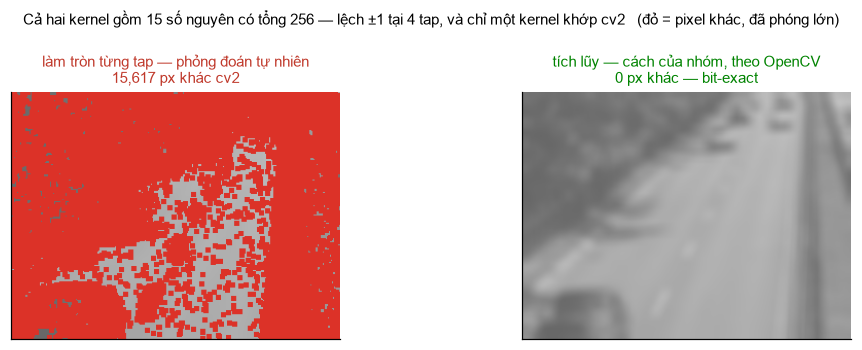

**▸ Fixed-point chain của nhóm: 0 trên 230,400 giá trị kênh khác cv2. Một Gaussian float64 *đúng* khác trên 14.8% — độ lệch này thuộc về OpenCV, và muốn khớp thì phải kế thừa nó.**

In [7]:
from gmm_mask.gpu.blur_kernels import gaussian_kernel_q8, blur_reference
from settings import BLUR_KSIZE, BLUR_SIGMA

k   = cv2.getGaussianKernel(BLUR_KSIZE, BLUR_SIGMA).ravel()
KQ  = gaussian_kernel_q8()                       # cumulative — what OpenCV does
per = np.rint(k * 256).astype(KQ.dtype)          # per-tap — the obvious guess

# blur ONE real frame both ways and compare each result with cv2, pixel by pixel
img = (cv2.imread(f"{HIGHWAY}/input/in000700.jpg") if HAS_DATA
       else np.random.default_rng(0).integers(0, 256, (240, 320, 3), np.uint8))
ref = cv2.GaussianBlur(img, (BLUR_KSIZE, BLUR_KSIZE), BLUR_SIGMA)
show = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
DIL = np.ones((5, 5), np.uint8)                  # differences enlarged for visibility

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
for ax, kern, name, col in [(axes[0], per, "làm tròn từng tap — phỏng đoán tự nhiên", C["v2"]),
                            (axes[1], KQ,  "tích lũy — cách của nhóm, theo OpenCV",  C["good"])]:
    d = (blur_reference(img, kern) != ref).any(axis=2)
    n = int(d.sum())
    overlay = np.stack([show]*3, -1) // 2 + 96
    overlay[cv2.dilate(d.astype(np.uint8), DIL) > 0] = [220, 50, 40]
    ax.imshow(overlay); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}\n{n:,} px khác cv2" if n else
                 f"{name}\n0 px khác — bit-exact", fontsize=9.5, color=col)
fig.suptitle("Cả hai kernel gồm 15 số nguyên có tổng 256 — lệch ±1 tại 4 tap, "
             "và chỉ một kernel khớp cv2   (đỏ = pixel khác, đã phóng lớn)", fontsize=9.5)
plt.tight_layout(); plt.show()

rng = np.random.default_rng(0); bad = tot = 0
for s in range(4):
    t = rng.integers(0, 256, (120, 160, 3), dtype=np.uint8)
    d = blur_reference(t, KQ) != cv2.GaussianBlur(t, (BLUR_KSIZE, BLUR_KSIZE), BLUR_SIGMA)
    bad += int(d.sum()); tot += d.size
ideal = np.floor(cv2.sepFilter2D(t.astype(np.float64), cv2.CV_64F, k, k,
                 borderType=cv2.BORDER_REFLECT_101) + .5).astype(np.uint8)
gap = (np.abs(ideal.astype(int) - blur_reference(t, KQ).astype(int)) != 0).mean()
take(f"Fixed-point chain của nhóm: {bad} trên {tot:,} giá trị kênh khác cv2. "
     f"Một Gaussian float64 *đúng* khác trên {gap:.1%} — độ lệch này thuộc về OpenCV, và muốn khớp thì phải kế thừa nó.")

Toàn bộ đường xử lý số nguyên cho cùng kết quả dưới các rounding mode và compiler flag khác nhau: **không có pixel nào khác trên cả bốn bản build OpenCV đã kiểm thử, ở ARM lẫn x86**. Cách làm tròn từng tap tạo 15,617 pixel lệch, còn cách tích lũy Q8 đưa con số về 0. Đây là hệ quả quan trọng của lựa chọn Q8 fixed-point; model kernel dùng float32 (số thực dấu phẩy động độ chính xác đơn) không thể đưa ra bảo đảm đó vì sai khác biên vẫn phụ thuộc compiler.

### 2.5 · Giai đoạn được giữ lại trên CPU

`fill_holes` của OpenCV dùng scan-line flood fill (tô vùng lần lượt theo từng hàng), vốn mang tính tuần tự. Có một phương án song song: lặp phép dilate từng pixel từ biên vào trong. Câu hỏi thực tế là chi phí của phương án này có đáng để chuyển lên GPU hay không.

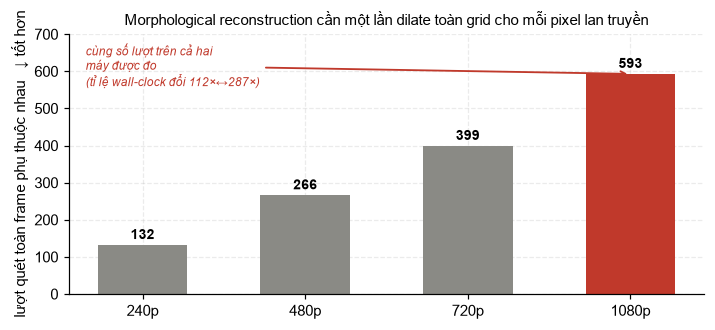

**▸ Dù CUDA dilate nhanh hơn một trăm lần, vẫn phải chạy tuần tự đủ 593 lượt. Xác định giai đoạn KHÔNG nên chuyển cũng là một kết quả.**

In [8]:
PASSES = {"240p": 132, "480p": 266, "720p": 399, "1080p": 593}
fig, ax = plt.subplots(figsize=(6.6, 3.1))
cols = [C["muted"]]*3 + [C["v2"]]
b = ax.bar(list(PASSES), list(PASSES.values()), .55, color=cols)
ax.bar_label(b, fmt="%d", fontsize=9, fontweight="bold", padding=2)
ax.set_ylabel("lượt quét toàn frame phụ thuộc nhau   ↓ tốt hơn"); ax.set_ylim(0, 700)
ax.set_title("Morphological reconstruction cần một lần dilate toàn grid cho mỗi pixel lan truyền",
             fontsize=10)
ax.annotate("cùng số lượt trên cả hai\nmáy được đo\n(tỉ lệ wall-clock đổi 112×↔287×)",
            xy=(3, 593), xytext=(-0.35, 560), fontsize=8, style="italic", color=C["v2"],
            arrowprops=dict(arrowstyle="->", color=C["v2"], lw=1.2))
plt.tight_layout(); plt.show()
take("Dù CUDA dilate nhanh hơn một trăm lần, vẫn phải chạy tuần tự đủ 593 lượt. "
     "Xác định giai đoạn KHÔNG nên chuyển cũng là một kết quả.")

*Mỗi kích thước dùng một mask tổng hợp có seed cố định và timing trên CPU. Nhóm không xây dựng bản CUDA reconstruction. Kết quả chỉ cho thấy cách hiện thực này cần hàng trăm lượt phụ thuộc nhau; nó không khẳng định mọi parallel flood fill đều chậm.*

Đây là **Partial GPU Principle** của môn học: *“xác định một hoặc hai phép toán chi phối runtime rồi tăng tốc đúng các phép toán đó — không viết lại toàn bộ ứng dụng.”* Trong pipeline này, phép đo cho thấy giữ flood fill trên CPU là quyết định có cơ sở, không phải một phần việc bị bỏ sót.

### 2.6 · Chọn post chain bằng phép đo

Nhóm kiểm thử mười ba candidate chain trong hai color space trên toàn bộ khoảng 470–1700.
Biểu đồ đọc trực tiếp kết quả đã commit từ `benchmarks/records/eval_highway_full.txt`, nhờ đó mỗi lựa chọn đều truy ngược được về cùng một record.

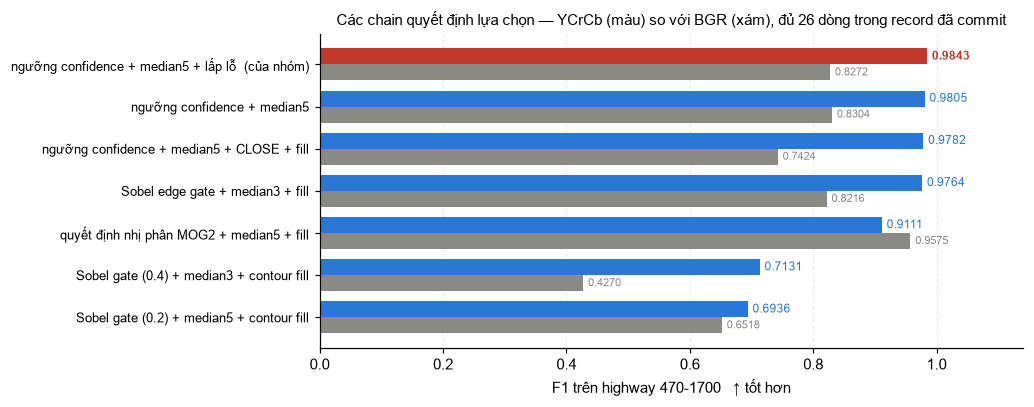

**▸ Color space ảnh hưởng hơn mọi lựa chọn post-processing: shipping chain đạt 0.827 trên BGR và 0.9843 trên YCrCb.**

In [9]:
import re

def parse_record(path="benchmarks/records/eval_highway_full.txt"):
    """(colorspace, chain, F1, IoU, P, R) rows straight from the committed run."""
    rows, cs = [], None
    for line in open(path):
        m = re.match(r"highway 470-1700 .*model input = (\w+)", line.strip())
        if m: cs = m.group(1); continue
        m = re.match(r"\s{2}(\S.*?)\s{2,}([\d.]{6})\s+([\d.]{6})\s+([\d.]{6})\s+([\d.]{6})\s+(\d+)\s+([\d.]+)$", line.rstrip())
        if m and cs:
            rows.append((cs, m.group(1).strip(), *map(float, m.groups()[1:5])))
    return rows

rows = parse_record()
SHIP = "bg_prob + median5 + fill"
# the chains the decision actually turned on; all 26 rows stay in the committed record
KEY = [SHIP, "bg_prob + median5", "mask + median5 + fill",
       "sobel gate + median3 + fill", "bg_prob + median5 + close15 + fill",
       "Tin dd40d92: gate.4 + med3 + contour",
       "Tin 1fe1c5e: gate.2 + med5 + contour+fill"]
f1 = {(r[0], r[1]): r[2] for r in rows}
KEY = sorted(KEY, key=lambda c: f1[("ycrcb", c)])
DISPLAY = {  # method descriptions for the axis; record keys stay as committed
    "bg_prob + median5 + fill":            "ngưỡng confidence + median5 + lấp lỗ  (của nhóm)",
    "bg_prob + median5":                   "ngưỡng confidence + median5",
    "bg_prob + median5 + close15 + fill":  "ngưỡng confidence + median5 + CLOSE + fill",
    "mask + median5 + fill":               "quyết định nhị phân MOG2 + median5 + fill",
    "sobel gate + median3 + fill":         "Sobel edge gate + median3 + fill",
    "Tin dd40d92: gate.4 + med3 + contour":      "Sobel gate (0.4) + median3 + contour fill",
    "Tin 1fe1c5e: gate.2 + med5 + contour+fill": "Sobel gate (0.2) + median5 + contour fill",
}

fig, ax = plt.subplots(figsize=(9.5, 3.8))
y = np.arange(len(KEY))
for c, yy in zip(KEY, y):
    col = C["v2"] if c == SHIP else C["v0"]
    ax.barh(yy + .19, f1[("ycrcb", c)], .38, color=col)
    ax.barh(yy - .19, f1[("bgr", c)], .38, color=C["muted"])
    ax.text(f1[("ycrcb", c)] + .008, yy + .19, f'{f1[("ycrcb", c)]:.4f}', va="center",
            fontsize=8, fontweight="bold" if c == SHIP else "normal", color=col)
    ax.text(f1[("bgr", c)] + .008, yy - .19, f'{f1[("bgr", c)]:.4f}', va="center",
            fontsize=7.5, color=C["muted"])
ax.set_yticks(y); ax.set_yticklabels([DISPLAY.get(c, c) for c in KEY], fontsize=8.5)
ax.set_xlim(0, 1.14); ax.set_xlabel("F1 trên highway 470-1700   ↑ tốt hơn")
ax.set_title("Các chain quyết định lựa chọn — YCrCb (màu) so với BGR (xám), "
             "đủ 26 dòng trong record đã commit", fontsize=10)
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

take(f'Color space ảnh hưởng hơn mọi lựa chọn post-processing: shipping chain đạt '
     f'{f1[("bgr", SHIP)]:.3f} trên BGR và {f1[("ycrcb", SHIP)]:.4f} trên YCrCb.')

**Bảng số liệu đã thay đổi ba lựa chọn ban đầu của nhóm:**

- **Loại morphological CLOSE.** Phép này lấp lỗ bằng cách mở rộng mask, khiến các xe gần nhau có thể dính qua phần mặt đường. Precision giảm từ `0.9863 → 0.9634`, trong khi **F1 chỉ dịch 0.006**; vì vậy điểm tổng hợp che khuất lỗi hình dạng nhìn thấy rõ.
- **Loại contour-fill alternative chain.** Thay đổi kết hợp này chỉ đạt precision **0.55** và tô cả phần đường giữa các xe. Kết quả không cô lập contour fill là nguyên nhân duy nhất, nhưng đủ cho thấy toàn chain không phù hợp để phát hành.
- **Threshold confidence thay vì dùng quyết định trực tiếp của MOG2.** MOG2 đánh dấu background sau *bất kỳ* lần match nào; yêu cầu ít nhất một nửa tổng weight đem lại **+7 F1**, nên confidence chứa tín hiệu hữu ích hơn quyết định nhị phân sớm.
- **Biến thể Sobel edge-gate xứng đáng được kiểm thử:** ở dạng raw, nó hơn raw bg_prob (0.9102 so với 0.9098). Tuy nhiên, full chain tốt nhất chỉ đạt 0.9764 so với 0.9843 của shipping chain, còn các biến thể contour-fill tụt xuống 0.71/0.69. Phép đo quyết định lựa chọn cuối, không phải sở thích.

## 3 · Đánh giá

### 3.1 · Parity giữa các hiện thực

Tính đúng đắn trước, tốc độ sau. Trên các chuỗi tổng hợp, parity (đầu ra khớp giữa các hiện thực) cho mask giống nhau đến từng bit. Trên 1231 frame thực: **chỉ 2 pixel khác trong 94.5 triệu pixel**, và từng trường hợp đều được chứng minh riêng (record: `benchmarks/records/t4_final_run.txt`). Một pixel nằm ngay ngưỡng 0.5 (0.4999971 so với 0.5000015); pixel còn lại bắt nguồn từ một phép so sánh mà hai compiler làm tròn lệch một ulp (bước float nhỏ nhất). Phán quyết cho cả v1 và v2 là **FLOAT-BOUNDARY**; mọi giai đoạn số nguyên đều bit-exact, tolerance bằng không.

⏱ *Cell chạy trực tiếp: chỉ `tests/test_parity.py`. Toàn bộ test suite: 76 passed trên T4 tại `f6c0bfc`.*

In [10]:
r = subprocess.run([sys.executable,"-m","pytest","tests/test_parity.py","-q","--no-header",
                    "-p","no:cacheprovider"], capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])
if HAS_GPU:
    take("Các test parity tổng hợp đã đạt trên GPU này; phép quét video thực được báo cáo riêng.")
else:
    take("Lần chạy local này chỉ kiểm tra các CPU path; record T4 đã commit là bằng chứng GPU.")

5 passed, 11 skipped in 0.73s


**▸ Lần chạy local này chỉ kiểm tra các CPU path; record T4 đã commit là bằng chứng GPU.**

### 3.2 · Độ đúng so với MOG2 của OpenCV

Phép kiểm tra trực tiếp riêng này so sánh 120 frame với MOG2 của OpenCV. Trong lần chạy này, **3 px trên 9 216 000 (0.00003 %)** khác nhau. Không quan sát thấy sai khác tăng dần trong các frame đó. Hình này không tái sử dụng kết quả GPU-parity ở §3.1, nên nó là một nguồn bằng chứng độc lập.

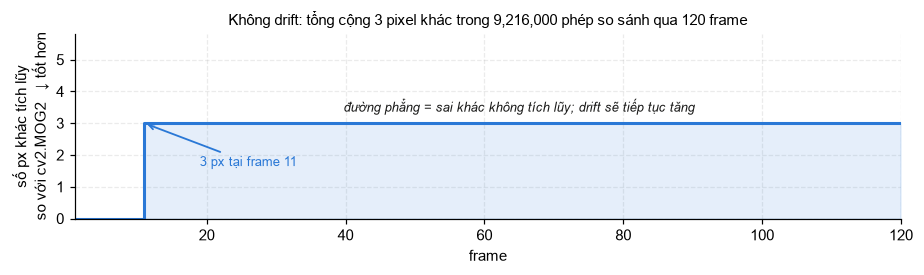

**▸ Đường chỉ nhảy một lần rồi nằm ngang: sai khác không tích lũy — hiện thực không drift ngày càng xa OpenCV.**

In [11]:
from gmm_mask import GMM_Mask_Numba
from settings import (MOG2_HISTORY, MOG2_VAR_THRESHOLD, MOG2_N_COMPONENTS,
                      MOG2_BACKGROUND_RATIO)

if HAS_DATA:
    ours = None
    cvm = cv2.createBackgroundSubtractorMOG2(history=int(MOG2_HISTORY),
            varThreshold=float(MOG2_VAR_THRESHOLD), detectShadows=False)
    cvm.setNMixtures(int(MOG2_N_COMPONENTS)); cvm.setBackgroundRatio(float(MOG2_BACKGROUND_RATIO))
    per_frame = []
    for i in range(1, 121):
        bgr = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
        if ours is None: ours = GMM_Mask_Numba(*bgr.shape[:2])
        m, _, _ = ours.apply(np.ascontiguousarray(bgr, np.float32))
        per_frame.append(int((np.asarray(m) != cvm.apply(bgr)).sum()))

    px = 120 * bgr.shape[0] * bgr.shape[1]
    cum = np.cumsum(per_frame)
    fig, ax = plt.subplots(figsize=(8.5, 2.6))
    ax.step(range(1, 121), cum, where="post", color=C["v0"], lw=2)
    ax.fill_between(range(1, 121), cum, step="post", color=C["v0"], alpha=.12)
    first = next(f for f, n in enumerate(per_frame, 1) if n)
    ax.annotate(f"{per_frame[first-1]} px tại frame {first}", xy=(first, cum[first-1]),
                xytext=(first + 8, cum[first-1] * .55), fontsize=8.5, color=C["v0"],
                arrowprops=dict(arrowstyle="->", color=C["v0"], lw=1.2))
    ax.text(65, cum[-1] * 1.12, "đường phẳng = sai khác không tích lũy; drift sẽ tiếp tục tăng",
            fontsize=8.5, style="italic", color=C["ink"], ha="center")
    ax.set_xlim(1, 120); ax.set_ylim(0, cum[-1] * 1.6 + 1)
    ax.set_xlabel("frame")
    ax.set_ylabel("số px khác tích lũy\nso với cv2.MOG2   ↓ tốt hơn")
    ax.set_title(f"Không drift: tổng cộng {cum[-1]} pixel khác trong {px:,} phép so sánh qua 120 frame",
                 fontsize=10)
    plt.tight_layout(); plt.show()
    take("Đường chỉ nhảy một lần rồi nằm ngang: sai khác không tích lũy — "
         "hiện thực không drift ngày càng xa OpenCV.")


- **Cách đọc:** đường biểu diễn số pixel tích lũy mà mask của nhóm khác với mask của cv2 qua 120 frame; nếu đường tiếp tục tăng thì sai khác đang tích tụ.
- **Nhìn vào:** đường chỉ nhảy một lần 3 px ở frame 11, rồi nằm ngang trong 110 frame còn lại; không có bước nhảy mới về sau.
- **Kết luận:** sai khác không tích lũy theo thời gian, nên hiện thực của nhóm không drift ngày càng xa OpenCV; đây là lệch cục bộ chứ không phải lỗi state lan truyền.

### 3.3 · Đối chiếu mask với nhãn

Trước hết chấm ba frame, sau đó đặt một frame cố định cạnh OpenCV để nhìn rõ khác biệt về hậu xử lý.

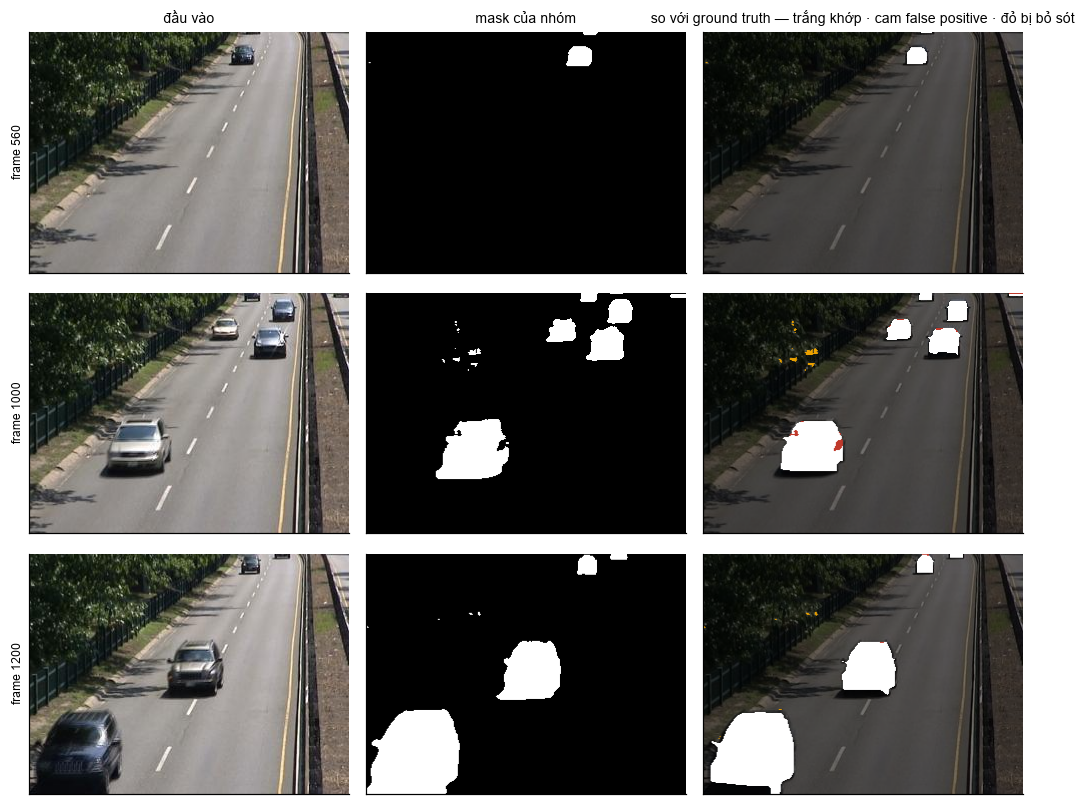

**▸ Lỗi nằm ở biên vật thể và vùng bóng, không bao phủ cả chiếc xe.**

In [12]:
from utils.post_processing import refine_mask, fill_holes, threshold_bg_prob

if HAS_DATA:
    m = GMM_Mask_Numba(240, 320)
    keep, want = {}, [560, 1000, 1200]
    for i in range(1, max(want) + 1):
        bgr = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
        mask, bg_prob, _ = m.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb))
        if i in want:
            keep[i] = (bgr.copy(),
                       refine_mask(np.asarray(mask), bg_prob=np.asarray(bg_prob)),
                       cv2.imread(f"{HIGHWAY}/groundtruth/gt{i:06d}.png", 0))

    fig, axes = plt.subplots(len(want), 3, figsize=(9.5, 2.5 * len(want)))
    for row, i in zip(axes, want):
        bgr, ours_m, gt = keep[i]
        valid = (gt == 255) | (gt == 0)
        ok = (ours_m == 255) & (gt == 255)
        fp = (ours_m == 255) & (gt == 0)
        fn = (ours_m == 0) & (gt == 255)
        overlay = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(float) * .45
        overlay[ok] = [255, 255, 255]           # agreement
        overlay[fp] = [235, 161, 0]             # we say fg, label says bg
        overlay[fn] = [192, 57, 43]             # we miss it
        row[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); row[0].set_ylabel(f"frame {i}", fontsize=8)
        row[1].imshow(ours_m, cmap="gray")
        row[2].imshow(overlay.astype(np.uint8))
        for a in row: a.set_xticks([]); a.set_yticks([])
    axes[0][0].set_title("đầu vào", fontsize=9)
    axes[0][1].set_title("mask của nhóm", fontsize=9)
    axes[0][2].set_title("so với ground truth — trắng khớp · cam false positive · đỏ bị bỏ sót", fontsize=9)
    plt.tight_layout(); plt.show()
    take("Lỗi nằm ở biên vật thể và vùng bóng, không bao phủ cả chiếc xe.")

- **Cách đọc:** trắng = khớp nhãn; cam = nhóm đánh dấu foreground nhưng nhãn là background; đỏ = foreground bị bỏ sót. Cách tô này tách đúng loại lỗi thay vì chỉ cho một điểm F1.
- **Nhìn vào:** các lỗi có màu tập trung ở biên vật thể và vùng bóng, không bao phủ trọn một chiếc xe; hình dạng chính của phương tiện vẫn được giữ.
- **Kết luận:** phần mà F1 0.9843 chưa bắt đúng chủ yếu là pixel biên, không phải bỏ sót xe; vì vậy sai số còn lại ít ảnh hưởng đến mục tiêu giữ xe sắc nét.

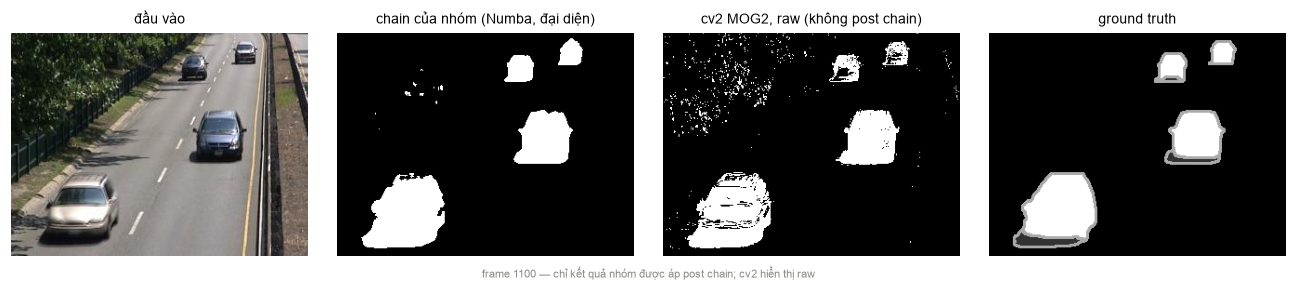

**▸ Numba đại diện cho cả năm hiện thực ở đây: synthetic parity đã bao phủ tất cả, còn parity trên frame thực đã ghi nhận của CUDA v1/v2 chỉ khác tại 2 pixel float-boundary đã chứng minh.**

In [13]:
# One fixed frame, judged three ways: our shipping chain, OpenCV's MOG2, the label.
# Fresh models, warmed together from frame 1 — equal model age, each fed its own
# documented input (ours YCrCb, cv2 BGR); the post chain is applied to ours only.
if HAS_DATA:
    F = 1100
    ours2 = GMM_Mask_Numba(240, 320)
    cvm2 = cv2.createBackgroundSubtractorMOG2(history=int(MOG2_HISTORY),
            varThreshold=float(MOG2_VAR_THRESHOLD), detectShadows=False)
    cvm2.setNMixtures(int(MOG2_N_COMPONENTS)); cvm2.setBackgroundRatio(float(MOG2_BACKGROUND_RATIO))
    for i in range(1, F + 1):
        bgr = cv2.imread(f"{HIGHWAY}/input/in{i:06d}.jpg")
        mask, bg_prob, _ = ours2.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb))
        cv_mask = cvm2.apply(bgr)
    ours_m = refine_mask(np.asarray(mask), bg_prob=np.asarray(bg_prob))
    gt = cv2.imread(f"{HIGHWAY}/groundtruth/gt{F:06d}.png", 0)
    panels = [("đầu vào", cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)),
              ("chain của nhóm (Numba, đại diện)", ours_m),
              ("cv2 MOG2, raw (không post chain)", cv_mask),
              ("ground truth", gt)]
    fig, ax = plt.subplots(1, 4, figsize=(12, 2.6))
    for a, (t, im) in zip(ax, panels):
        a.imshow(im, cmap=None if im.ndim == 3 else "gray")
        a.set_title(t, fontsize=9); a.axis("off")
    fig.suptitle(f"frame {F} — chỉ kết quả nhóm được áp post chain; cv2 hiển thị raw", fontsize=7.5, y=.02, color=C["muted"])
    plt.tight_layout(); plt.show()
    take("Numba đại diện cho cả năm hiện thực ở đây: synthetic parity đã bao phủ tất cả, "
         "còn parity trên frame thực đã ghi nhận của CUDA v1/v2 chỉ khác tại 2 pixel float-boundary đã chứng minh.")

- **Cách đọc:** cùng một frame đi qua full chain của nhóm, qua raw cv2 MOG2 (không có post chain), rồi so với nhãn thủ công; ba cột cho thấy riêng tác động của hậu xử lý.
- **Nhìn vào:** chain của nhóm tạo hình xe đặc và liền, trong khi raw library mask còn lỗ và nhiễu đốm; nhãn cho mốc tham chiếu trực quan.
- **Kết luận:** một model CPU đại diện cho cả năm hiện thực trong hình này vì synthetic parity đã bao phủ chúng; trên frame thực, parity chỉ khác 2 pixel biên đã được chứng minh.

### 3.4 · Throughput trên frame tổng hợp

Đây là thang hiệu năng đã ghi nhận trên T4 — cũng là số liệu thực tế dùng để kiểm tra mọi dự đoán ở §4.1.

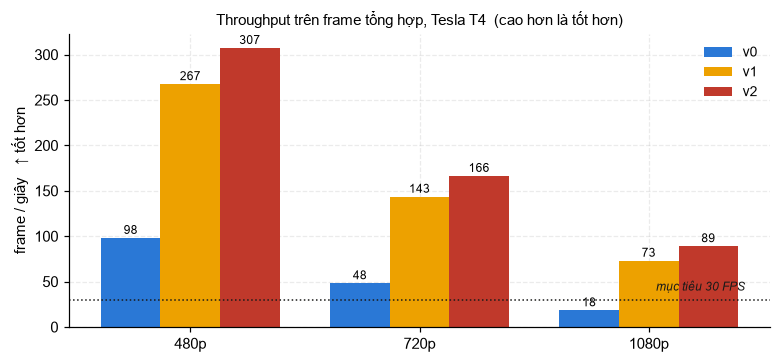

**▸ 88.8 FPS tại 1080p — bằng 4.89× baseline v0 và 2.9× mục tiêu 30 FPS. Mục tiêu còn lại của proposal, >20× so với Sequential Python, đạt 887× tại 480p (RESULTS-T4 §3: tuần tự 3 034.62 ms/frame).**

In [14]:
x = np.arange(3); w = .26
fig, ax = plt.subplots(figsize=(7.2, 3.4))
for i, v in enumerate(("v0", "v1", "v2")):
    b = ax.bar(x + (i-1)*w, T4[v]["fps"], w, label=v, color=C[v])
    ax.bar_label(b, fmt="%.0f", fontsize=8, padding=1)
ax.axhline(30, color=C["ink"], lw=1, ls=":")
ax.text(2.42, 40, "mục tiêu 30 FPS", ha="right", fontsize=8, style="italic", color=C["ink"])
ax.set_xticks(x); ax.set_xticklabels(SIZES)
ax.set_ylabel("frame / giây   ↑ tốt hơn")
ax.set_title("Throughput trên frame tổng hợp, Tesla T4  (cao hơn là tốt hơn)", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

sp = T4["v0"]["ms"][2] / T4["v2"]["ms"][2]
take(f"88.8 FPS tại 1080p — bằng {sp:.2f}× baseline v0 và 2.9× mục tiêu 30 FPS. "
     "Mục tiêu còn lại của proposal, >20× so với Sequential Python, đạt 887× "
     "tại 480p (RESULTS-T4 §3: tuần tự 3 034.62 ms/frame).")

- **Cách đọc:** số frame xử lý mỗi giây trên dữ liệu tổng hợp; đường chấm là mục tiêu thời gian thực 30 FPS, nên cột vượt đường là đạt yêu cầu.
- **Nhìn vào:** v2 đạt 88.8 FPS tại 1080p — bằng 4.89× v0 và 2.9× mục tiêu; khoảng cách vẫn rõ ngay ở độ phân giải lớn nhất.
- **Kết luận:** cả hai mục tiêu trong proposal đều hoàn tất: 30 FPS tại 1080p và >20× so với Sequential Python (887× tại 480p, cùng protocol).

### 3.5 · Throughput trên cảnh quay thực

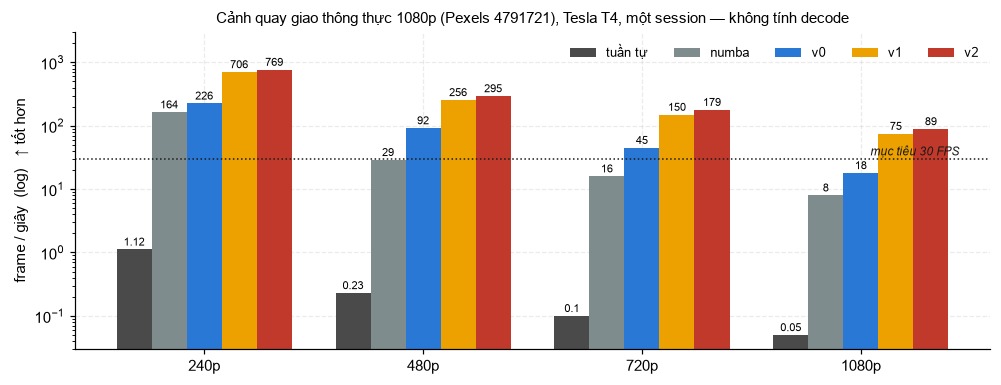

**▸ 89 FPS tại 1080p trên cảnh quay thực — bằng 4.9× v0, 11.8× CPU đã biên dịch và 1,933× Sequential Python; tất cả được đo trên cùng clip, trong cùng session.**

In [15]:
# The referee question about every synthetic-frame table: does the speedup
# survive a real decoder and real footage? Same clip, same session, five
# implementations — log scale so 0.05 FPS and 769 FPS fit on one axis.
RF = REALFOOTAGE_T4
xs = np.arange(len(RF["tiers"])); w = .16
fig, ax = plt.subplots(figsize=(9.2, 3.6))
for i, (v, col) in enumerate((("seq", "#4a4a4a"), ("numba", "#7f8c8d"),
                              ("v0", C["v0"]), ("v1", C["v1"]), ("v2", C["v2"]))):
    b = ax.bar(xs + (i - 2) * w, RF[v]["fps"], w,
               label="tuần tự" if v == "seq" else v, color=col)
    ax.bar_label(b, labels=[f"{f:g}" for f in RF[v]["fps"]], fontsize=7, padding=1)
ax.axhline(30, color=C["ink"], lw=1, ls=":")
ax.text(3.45, 34, "mục tiêu 30 FPS", ha="right", fontsize=8, style="italic", color=C["ink"])
ax.set_yscale("log"); ax.set_ylim(.03, 3000)
ax.set_xticks(xs); ax.set_xticklabels(RF["tiers"])
ax.set_ylabel("frame / giây  (log)   ↑ tốt hơn")
ax.set_title("Cảnh quay giao thông thực 1080p (Pexels 4791721), Tesla T4, một session — không tính decode",
             fontsize=10)
ax.legend(frameon=False, fontsize=8.5, ncols=5)
plt.tight_layout(); plt.show()

r_seq = RF["seq"]["ms"][3] / RF["v2"]["ms"][3]
take(f"89 FPS tại 1080p trên cảnh quay thực — bằng {RF['v0']['ms'][3]/RF['v2']['ms'][3]:.1f}× v0, "
     f"{RF['numba']['ms'][3]/RF['v2']['ms'][3]:.1f}× CPU đã biên dịch và {r_seq:,.0f}× "
     "Sequential Python; tất cả được đo trên cùng clip, trong cùng session.")

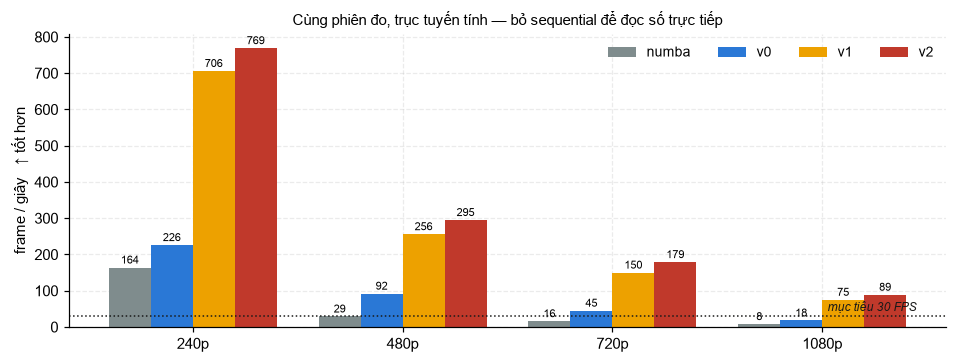

In [16]:
# Cùng dữ liệu, bỏ sequential (0.05–1.12 FPS) và về trục tuyến tính —
# đọc số trực tiếp, không cần quen log scale.
RF = REALFOOTAGE_T4
xs = np.arange(len(RF["tiers"])); w = .2
fig, ax = plt.subplots(figsize=(8.8, 3.4))
for i, (v, col) in enumerate((("numba", "#7f8c8d"), ("v0", C["v0"]),
                              ("v1", C["v1"]), ("v2", C["v2"]))):
    b = ax.bar(xs + (i - 1.5) * w, RF[v]["fps"], w, label=v, color=col)
    ax.bar_label(b, fmt="%.0f", fontsize=7.5, padding=1)
ax.axhline(30, color=C["ink"], lw=1, ls=":")
ax.text(3.45, 44, "mục tiêu 30 FPS", ha="right", fontsize=8, style="italic", color=C["ink"])
ax.set_xticks(xs); ax.set_xticklabels(RF["tiers"])
ax.set_ylabel("frame / giây   ↑ tốt hơn")
ax.set_title("Cùng phiên đo, trục tuyến tính — bỏ sequential để đọc số trực tiếp", fontsize=10)
ax.legend(frameon=False, fontsize=9, ncols=4)
plt.tight_layout(); plt.show()

- **Cách đọc:** FPS trên clip thực ở thang log để 0.05 và 769 cùng nằm trên một trục; cả năm hiện thực được đo trong cùng một session để giảm sai lệch môi trường. Hình log phía trên cho thấy cả sequential; hình tuyến tính ngay dưới cùng dữ liệu, bỏ sequential để đọc số trực tiếp.
- **Nhìn vào:** v2 giữ 89 FPS tại 1080p, còn Sequential Python chỉ đạt 0.05 FPS trên đúng các frame đó; chênh lệch không đến từ dữ liệu tổng hợp dễ hơn.
- **Kết luận:** thang tối ưu vẫn đứng vững với decoder và cảnh quay thực — v1 lẫn v2 đều vượt 30 FPS ở mọi kích thước, trong khi v0 không còn đạt tại 1080p.

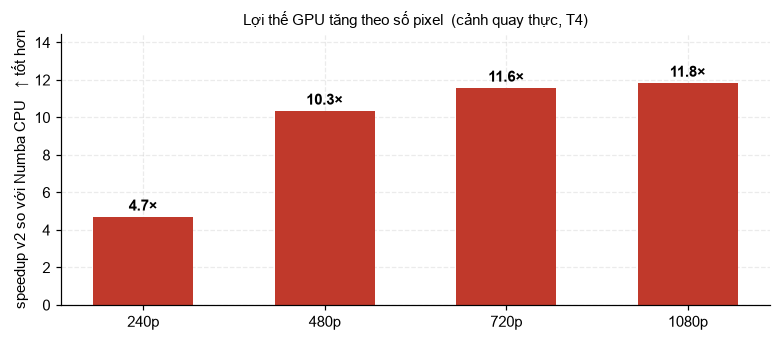

**▸ 11.8× so với CPU đã biên dịch tại 1080p — và 887× so với Sequential Python tại 480p, nhưng Numba CPU mới là baseline công bằng (RESULTS-T4 §3).**

In [17]:
# What did the GPU actually buy? v2 vs the compiled CPU baseline, same real
# footage, same protocol — computed live from the recorded table above.
RF = REALFOOTAGE_T4
sp = [n / v for n, v in zip(RF["numba"]["ms"], RF["v2"]["ms"])]
fig, ax = plt.subplots(figsize=(7.2, 3.2))
b = ax.bar(RF["tiers"], sp, .55, color=C["v2"])
ax.bar_label(b, labels=[f"{s:.1f}×" for s in sp], fontsize=10, fontweight="bold", padding=2)
ax.set_ylabel("speedup v2 so với Numba CPU   ↑ tốt hơn")
ax.set_title("Lợi thế GPU tăng theo số pixel  (cảnh quay thực, T4)", fontsize=10)
ax.set_ylim(0, max(sp) * 1.22)
plt.tight_layout(); plt.show()

take(f"{sp[-1]:.1f}× so với CPU đã biên dịch tại 1080p — và 887× so với Sequential "
     "Python tại 480p, nhưng Numba CPU mới là baseline công bằng (RESULTS-T4 §3).")

- **Cách đọc:** mỗi cột cho biết v2 nhanh gấp bao nhiêu lần baseline CPU đã biên dịch ở từng độ phân giải; cùng protocol giúp tỉ số phản ánh đúng lợi ích của GPU.
- **Nhìn vào:** speedup tăng đều từ 4.7× tại 240p lên 11.8× tại 1080p, theo đúng xu hướng số pixel và lượng song song tăng.
- **Kết luận:** lợi thế của GPU lớn dần theo số pixel và đạt cực đại đúng nơi yêu cầu thời gian thực khó nhất; chi phí cố định ở độ phân giải thấp cũng được amortize tốt hơn.

### 3.6 · Thời gian nằm ở đâu

Biểu đồ phân rã từng giai đoạn trong cả ba phiên bản. Phần xanh giảm từ v0→v1 khi ingest chuyển lên device, còn phần xám giảm từ v1→v2 nhờ tiling. **Phần đỏ gần như không đổi:** đó là flood fill đã phân tích ở §2.5.

Mức giảm ingest từ v0→v1 (23.21 → 1.65 ms tại 1080p) chủ yếu đến từ phần việc trên host được *loại bỏ* — conversion kernel mới trên device chỉ tốn 0.184 ms. Vì vậy, biểu đồ không chỉ cho biết giai đoạn nào nhanh hơn mà còn giải thích nguồn gốc của mức giảm.

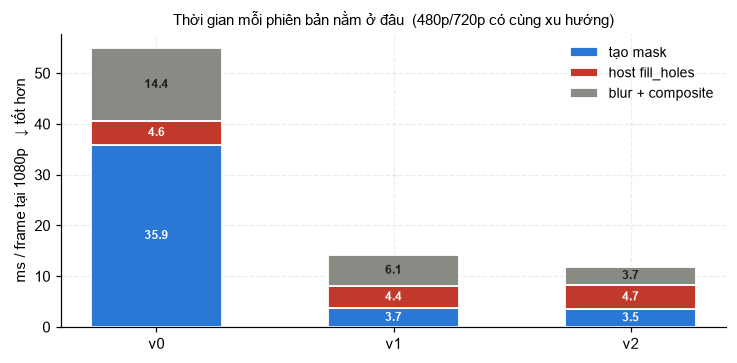

**▸ Tại 1080p, giai đoạn đơn lẻ lớn nhất của v2 hiện là host flood fill — 39.7%. Cơ hội tiếp theo là CUDA streams, không phải kernel nhanh hơn.**

In [18]:
stage_cols = {"mask production": C["v0"], "host fill_holes": C["v2"],
              "blur + composite": C["muted"]}
stage_labels = {"mask production": "tạo mask", "host fill_holes": "host fill_holes",
                "blur + composite": "blur + composite"}
fig, ax = plt.subplots(figsize=(6.8, 3.4))
bottom = np.zeros(3)
for stage, col in stage_cols.items():
    vals = [PERSTAGE[v][stage][2] for v in ("v0", "v1", "v2")]   # [2] = 1080p
    ax.bar(np.arange(3), vals, .55, bottom=bottom, color=col, label=stage_labels[stage],
           edgecolor="white", linewidth=1.2)
    for xi, (v, b0) in enumerate(zip(vals, bottom)):
        ax.text(xi, b0 + v/2, f"{v:.1f}", ha="center", va="center", fontsize=8,
                fontweight="bold", color="white" if col != C["muted"] else C["ink"])
    bottom += np.array(vals)
ax.set_xticks(np.arange(3)); ax.set_xticklabels(["v0", "v1", "v2"])
ax.set_ylabel("ms / frame tại 1080p   ↓ tốt hơn")
ax.set_title("Thời gian mỗi phiên bản nằm ở đâu  (480p/720p có cùng xu hướng)", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

tot = sum(v[2] for v in PERSTAGE["v2"].values())
take(f"Tại 1080p, giai đoạn đơn lẻ lớn nhất của v2 hiện là host flood fill — "
     f"{PERSTAGE['v2']['host fill_holes'][2]/tot:.1%}. Cơ hội tiếp theo là CUDA streams, không phải kernel nhanh hơn.")

- **Cách đọc:** mỗi cột là thời gian xử lý một frame 1080p của một phiên bản, chia theo từng pipeline stage; tổng chiều cao càng thấp thì frame hoàn tất càng sớm.
- **Nhìn vào:** model+ingest (xanh) và blur (xám) co lại từ v0 đến v2, còn host flood fill (đỏ) giữ quanh ≈4.7 ms ở cả ba; bottleneck vì thế dịch chuyển sang phần đỏ.
- **Kết luận:** fill hiện chiếm 39.7% thời gian frame của v2. Cơ hội tiếp theo là chồng lấp nó bằng CUDA streams, không phải chỉ làm kernel nhanh hơn, vì kernel không còn là phần chi phối duy nhất.

### 3.7 · Kết quả end-to-end

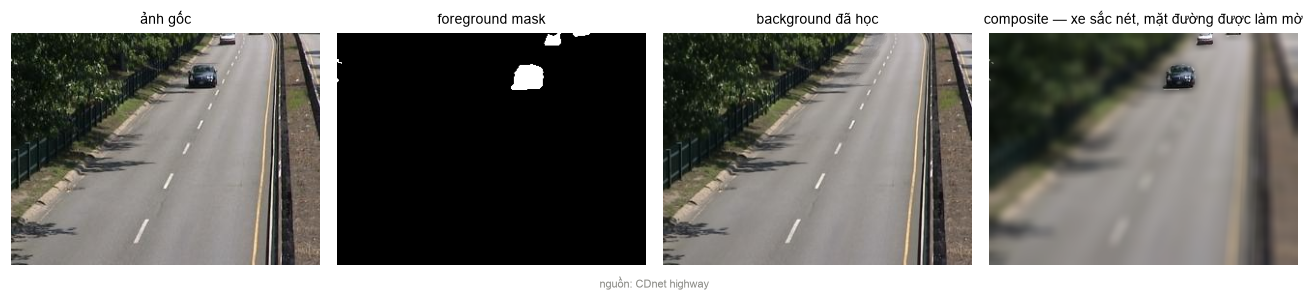

In [19]:
from utils.post_processing import background_blur
from settings import BLUR_KSIZE, BLUR_SIGMA

frames, src = load_sequence(600)
h, w = frames[0].shape[:2]
m = GMM_Mask_Numba(h, w)
for bgr in frames:
    mask, bg_prob, _ = m.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb))
refined = refine_mask(np.asarray(mask), bg_prob=np.asarray(bg_prob))
out = background_blur(bgr, refined, BLUR_KSIZE, BLUR_SIGMA)
bg  = cv2.cvtColor(m.background_image(), cv2.COLOR_YCrCb2RGB)  # model was fed YCrCb

fig, ax = plt.subplots(1, 4, figsize=(12, 2.7))
for a, (t, im) in zip(ax, [("ảnh gốc", cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)),
                           ("foreground mask", refined),
                           ("background đã học", bg),
                           ("composite — xe sắc nét, mặt đường được làm mờ",
                            cv2.cvtColor(out, cv2.COLOR_BGR2RGB))]):
    a.imshow(im, cmap=None if im.ndim == 3 else "gray")
    a.set_title(t, fontsize=9); a.axis("off")
fig.suptitle(f"nguồn: {src}", fontsize=7.5, y=.02, color=C["muted"])
plt.tight_layout(); plt.show()

- **Cách đọc:** theo dõi toàn pipeline trên một frame: đầu vào, foreground mask, background mà model đã học, rồi frame composite cuối cùng. Bốn ảnh cho phép kiểm tra cả trạng thái trung gian lẫn đầu ra.
- **Nhìn vào:** mask giữ vùng xe, learned background mô tả phần cảnh tĩnh, và composite chỉ làm mờ mặt đường cùng hậu cảnh; xe vẫn giữ biên sắc nét.
- **Kết luận:** sản phẩm hoạt động end-to-end đúng mục tiêu: xe được giữ nét, mặt đường được làm mờ, và kết quả cuối nhất quán với các bước trung gian.

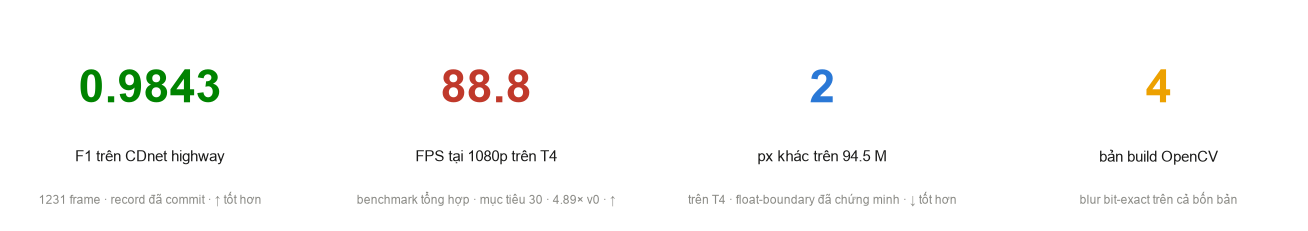

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2.2))
tiles = [("0.9843", "F1 trên CDnet highway", "1231 frame · record đã commit · ↑ tốt hơn", C["good"]),
         ("88.8", "FPS tại 1080p trên T4", "benchmark tổng hợp · mục tiêu 30 · 4.89× v0 · ↑",   C["v2"]),
         ("2", "px khác trên 94.5 M", "trên T4 · float-boundary đã chứng minh · ↓ tốt hơn", C["v0"]),
         ("4", "bản build OpenCV", "blur bit-exact trên cả bốn bản",                 C["v1"])]
for a, (big, label, sub, col) in zip(axes, tiles):
    a.axis("off")
    a.text(.5, .62, big, ha="center", va="center", fontsize=30, fontweight="bold", color=col)
    a.text(.5, .30, label, ha="center", va="center", fontsize=10, color=C["ink"])
    a.text(.5, .10, sub, ha="center", va="center", fontsize=8, color=C["muted"])
plt.tight_layout(); plt.show()

## 4 · Thảo luận

### 4.1 · Các dự đoán của nhóm: sai năm trên sáu

Cả sáu dự đoán dưới đây được giữ đúng như record trong `RESULTS-T4.md` §8 trước khi benchmark chạy; đặt cạnh số đo giúp thấy rõ sai lệch thay vì diễn giải lại sau khi biết kết quả:

| Dự đoán (viết trước) | Dự đoán | Đo được | Phán quyết |
|---|---|---|---|
| Host blur + composite @1080p | 4–8 ms | 13.7 ms | ✗ tệ hơn 2–3× |
| GPU blur kernels @1080p | 0.2–0.4 ms | 1.55 ms | ✗ tốn hơn ~4–8× |
| Mức tiết kiệm ingest + blur @1080p | 4–8 ms | ~34 ms | ✗ lớn hơn 4–8× |
| Mức giảm lưu lượng bus | −38.5% | −52.9% | ✗ lớn hơn |
| Tiled so với naive blur | *“có lẽ gần với naive”* | **nhanh hơn 2.36×** | ✗ — tốt hơn dự đoán |
| Bottleneck sau thay đổi | host `fill_holes` | xác nhận, 39.7% @1080p | ✓ dự đoán duy nhất đúng |

**Ba lần sai do đánh giá thấp chi phí host và bus. Một lần đánh giá thấp chi phí của GPU kernel. Một lần sai theo hướng ngược lại: tiling tốt hơn dự đoán.** Bảng này cho thấy tối ưu dựa trên linh cảm dễ sai ở cả hai hướng, nên mọi quyết định tiếp theo đều cần profile.

Kết quả tiling làm nhóm bất ngờ nhất. Nhóm từng cho rằng layout L2 đã cung cấp đủ khả năng tái sử dụng, nhưng shared-memory tile đem lại **2.36×** ở ba độ phân giải và dưới hai protocol đo. Việc ghi dự đoán trước khiến độ lệch hiện rõ, đồng thời buộc nhóm giải thích lợi ích bằng data reuse thay vì chỉ báo cáo con số tốt.

### 4.2 · Bài học rút ra

- **Host mới là bottleneck, không phải số học.** Loại bỏ phần việc trên host tạo ra 76 % mức tiết kiệm ở ingest; profile chỉ ra nơi tối ưu hiệu quả hơn việc đoán theo FLOP.
- **Số học Q8 fixed-point (số nguyên với scale cố định) giúp device blur bit-exact.** Đây là thắng lợi về tính đúng đắn, vì kết quả khớp OpenCV trên mọi bản build đã thử.
- **Phép đổi YCrCb số nguyên được xác thực riêng cho phép upload 3 B/px.** Đây là thắng lợi về truyền dữ liệu, vì frame không còn phải đổi thành float trước khi đi qua bus.
- **Một số giai đoạn nên ở lại CPU.** Flood fill cần 593 lượt phụ thuộc nhau (`bench_fill.py`); GrabCut tăng +2.1 F1 nhưng tốn chi phí ~141× nên đã bị loại (đo tại `aa4dfb7`, không thể tái lập từ checkout này). Hai kết quả cho thấy chất lượng và khả năng song song đều phải được cân nhắc.

## 5 · Kết luận

Một thuật toán, năm hiện thực, mọi khẳng định đều được kiểm thử. Chất lượng đạt **F1 0.9843** trên CDnet highway; tốc độ đạt **88.8 FPS** với dữ liệu tổng hợp và **89 FPS** với cảnh quay thực tại 1080p — hoàn tất cả hai mục tiêu proposal (30 FPS; >20× so với Sequential Python, thực tế đạt 887×). Mức thống nhất GPU-vs-CPU được chặn trên ở **2 pixel float-boundary đã chứng minh trong 94.5 M**. Speedup chủ yếu đến từ việc di chuyển ít dữ liệu hơn, không đơn thuần là tính toán nhanh hơn.

### 5.1 · Hạn chế
- Các host CDnet đang offline, nên nhóm phụ thuộc vào mirror trên HuggingFace.
- Kết quả floating-point có thể khác giữa các compiler theo thiết kế; nhóm đã chặn trên sai khác: 2 px trên 94.5 M, cả hai đều là trường hợp biên được chứng minh trên T4.
- Timing có thể dao động trên GPU Colab dùng chung.
- CUDASIM (trình mô phỏng CUDA chạy trên CPU) kiểm tra logic, nhưng hành vi GPU thực vẫn cần hardware test.

### 5.2 · Hướng phát triển

- **Pinned (page-locked) buffers + CUDA streams (bậc L4):** chồng lấp host flood fill với ingest của frame kế tiếp — fill hiện là giai đoạn đơn lẻ lớn nhất. Đây là hướng do profile chỉ ra, **không phải kết quả đã đạt**.
- **Fused separable blur:** hợp lệ (blur không có side effect, nên tính lại halo vẫn an toàn) nhưng chưa được đo — hai blur kernel chiếm ≈1.55 ms trong 11.07 ms tại 1080p, nên trần cải thiện không lớn.
- Một bộ dữ liệu 1080p đã gán nhãn sẽ cho phép chấm chất lượng đúng tại độ phân giải đang đo throughput.

**Tài liệu tham khảo & nguồn số liệu** <br>
*Zivkovic 2004 · Stauffer & Grimson 1999 · Wang et al., CDnet 2014* <br>
*OpenCV `bgfg_gaussmix2.cpp`, `smooth.simd.hpp`* <br>
*Phép đo: Colab T4 — `RESULTS-T4.md` · record chất lượng: `benchmarks/records/eval_highway_full.txt`*